# Air Quality ML Project: Notebook 04
## Regression: Predicting PM2.5 Concentration (Track C)

**Goal:** predict the *continuous* PM2.5 value (µg/m³) from the other pollutants,
weather and time features.

**Why this track matters most for Lab 6:** the six pollutants are strongly
correlated with one another (they share sources, traffic, coal burning, weather
inversions). That **multicollinearity** is precisely the condition under which
**Ridge, Lasso and ElasticNet** outperform plain linear regression. Most student
projects run regularisation without being able to justify it; this notebook shows
the evidence first, then the fix.

**Labs covered:** 5 (regression tree) · 6 (MLR, Polynomial, Ridge/Lasso/ElasticNet) ·
7 (Cross-Validation) · 8 (SVR) · 9 (MLP regressor) · 10 (Random Forest regressor) · 11 (Ensemble)

> Run **Notebook 01** first, this loads `beijing_aqi_clean.parquet`.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
print("Setup complete.")

Setup complete.


## 1. Load Data & Examine the Target

Rows with no PM2.5 reading have no ground truth, so they are dropped.

In [2]:
df = pd.read_parquet("beijing_aqi_clean.parquet")
print("Rows loaded:", f"{len(df):,}")
print("Rows with missing PM2.5 (dropped):", int(df["PM2.5"].isna().sum()))

df = df.dropna(subset=["PM2.5"]).copy()
print("Rows for regression:", f"{len(df):,}")
df["PM2.5"].describe().round(2)

Rows loaded: 420,768
Rows with missing PM2.5 (dropped): 8739
Rows for regression: 412,029


count    412029.00
mean         79.79
std          80.82
min           2.00
25%          20.00
50%          55.00
75%         111.00
max         999.00
Name: PM2.5, dtype: float64

### The target is heavily right-skewed
Most hours are moderately polluted, but a long tail of severe-smog events stretches
far to the right. This matters: squared-error losses (RMSE) are dominated by those
extreme hours, so every model will struggle most exactly where accuracy matters most.

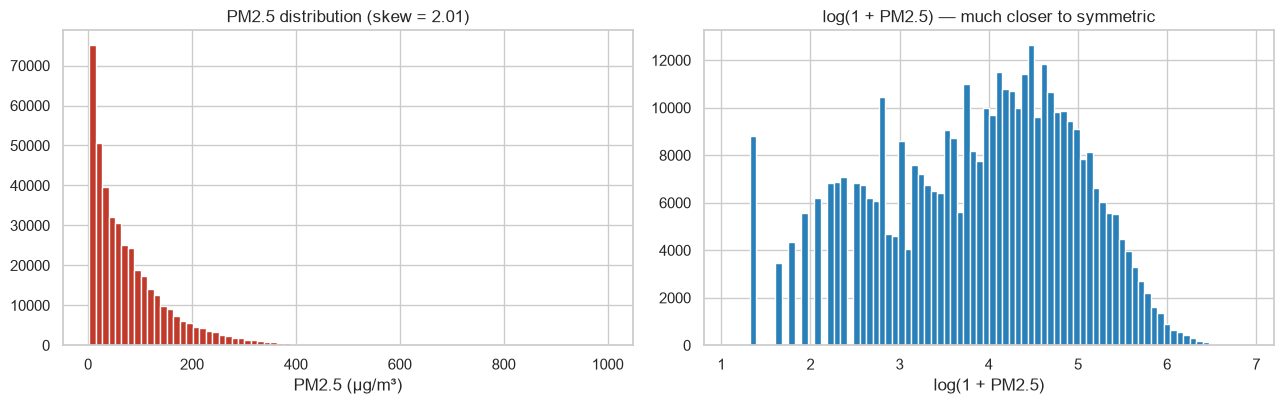

Skewness raw: 2.01   |   after log1p: -0.31


In [3]:
skew = df["PM2.5"].skew()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(df["PM2.5"], bins=80, color="#c0392b")
axes[0].set_title(f"PM2.5 distribution (skew = {skew:.2f})")
axes[0].set_xlabel("PM2.5 (µg/m³)")

axes[1].hist(np.log1p(df["PM2.5"]), bins=80, color="#2980b9")
axes[1].set_title("log(1 + PM2.5) — much closer to symmetric")
axes[1].set_xlabel("log(1 + PM2.5)")
plt.tight_layout(); plt.show()

print(f"Skewness raw: {skew:.2f}   |   after log1p: {np.log1p(df['PM2.5']).skew():.2f}")

## 2. Features

**No leakage rule needed this time.** In Notebooks 02–03 the targets were *derived
from* PM2.5, so it had to be excluded. Here PM2.5 **is** the target, and every other
column is a legitimate independent measurement.

One honest caveat to state: **PM10 is physically related to PM2.5**
(PM2.5 particles are a subset of PM10 by definition), so it will dominate the model.
That is a real predictive relationship from a separate sensor, not leakage, but it
does mean the task is "estimate fine particulates given coarse particulates and
conditions", which is easier than predicting from weather alone.

In [4]:
NUMERIC_FEATURES = ["PM10","SO2","NO2","CO","O3","TEMP","PRES","DEWP","RAIN","WSPM",
                    "hour_sin","hour_cos","month_sin","month_cos"]
CATEGORICAL_FEATURES = ["wd","station","season"]
TARGET = "PM2.5"

print(f"{len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical features")

14 numeric + 3 categorical features


## 3. ⭐ Evidence of Multicollinearity: the Case for Regularisation

Before reaching for Ridge/Lasso, let's *prove* the problem exists. Two pieces of evidence:

1. **Correlation matrix**. pairwise linear relationships.
2. **Variance Inflation Factor (VIF)**. how much a feature is explained by *all* the
   others combined. VIF = 1/(1 − R²) from regressing each feature on the rest.
   Rule of thumb: **VIF > 5 is concerning, > 10 is severe.**

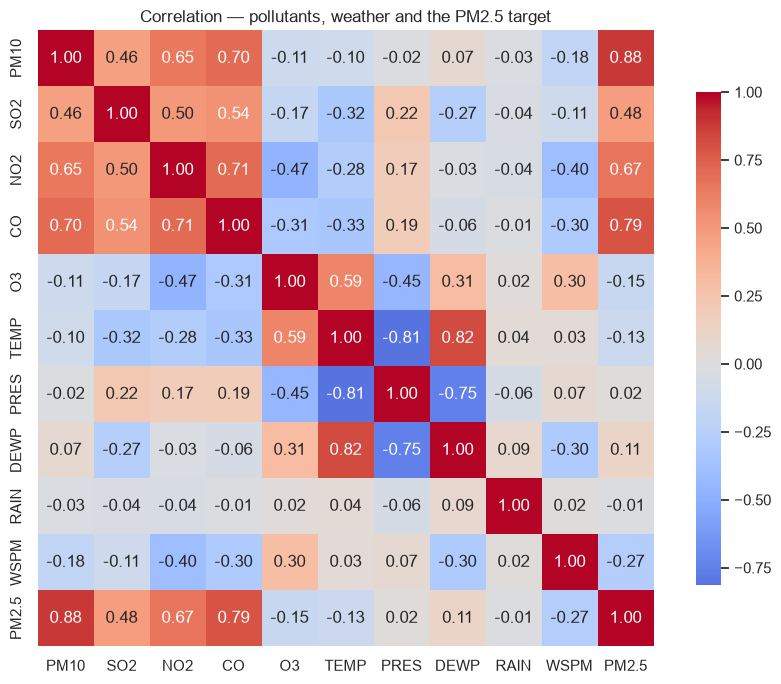

In [5]:
corr = df[NUMERIC_FEATURES[:10] + [TARGET]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation — pollutants, weather and the PM2.5 target")
plt.tight_layout(); plt.show()

In [6]:
def compute_vif(frame, features):
    """VIF for each feature = 1 / (1 - R^2) of regressing it on all other features."""
    X = frame[features].dropna()
    Xs = StandardScaler().fit_transform(X)
    vifs = []
    for i, name in enumerate(features):
        y_i = Xs[:, i]
        X_other = np.delete(Xs, i, axis=1)
        r2 = LinearRegression().fit(X_other, y_i).score(X_other, y_i)
        vifs.append(np.inf if r2 >= 1 else 1.0 / (1.0 - r2))
    return (pd.DataFrame({"Feature": features, "VIF": vifs})
              .sort_values("VIF", ascending=False).reset_index(drop=True))

vif_df = compute_vif(df, NUMERIC_FEATURES[:10])   # the 10 real measurements
vif_df["Severity"] = pd.cut(vif_df["VIF"], [0, 5, 10, np.inf],
                            labels=["OK", "Concerning", "Severe"])
vif_df.round(2)

,Feature,VIF,Severity
0,TEMP,7.95,Concerning
1,DEWP,5.74,Concerning
2,PRES,3.23,OK
3,NO2,3.19,OK
4,CO,3.03,OK
5,PM10,2.56,OK
6,O3,2.30,OK
7,SO2,1.70,OK
8,WSPM,1.65,OK
9,RAIN,1.02,OK


> **This table matters.** Any feature above 5 is substantially
> redundant given the others. High VIF makes ordinary least squares **unstable**:
> coefficients become large, sign-flippy and sensitive to small data changes, even
> while predictions stay decent. Ridge and ElasticNet fix exactly this by penalising
> large coefficients; Lasso additionally drives redundant ones to zero.

## 4. Configuration, Preprocessor & Split

For regression we use a plain `KFold` (no stratification, the target is continuous).

In [7]:
SAMPLE_SIZE = 20_000       # set to None for all ~412k rows
SVR_SAMPLE  = 4_000        # SVR is O(n^2) — always sampled

def build_preprocessor(poly_degree=1):
    """poly_degree=2 adds interaction/quadratic terms to the NUMERIC branch only."""
    steps = [("impute", SimpleImputer(strategy="median"))]
    if poly_degree > 1:
        steps.append(("poly", PolynomialFeatures(degree=poly_degree,
                                                 include_bias=False)))
    steps.append(("scale", StandardScaler()))
    numeric = Pipeline(steps)
    categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                     sparse_output=False))])
    return ColumnTransformer([("num", numeric, NUMERIC_FEATURES),
                              ("cat", categorical, CATEGORICAL_FEATURES)])

data = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE) \
         if SAMPLE_SIZE else df.copy()

X = data[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
print("Working set:", f"{len(data):,}", "rows")
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Feature count after encoding:",
      build_preprocessor().fit_transform(X_train).shape[1])

Working set: 20,000 rows
Train: (16000, 17)  Test: (4000, 17)
Feature count after encoding: 46


## 5. Evaluation Helpers

| Metric | Meaning | Units |
|---|---|---|
| **RMSE** | root mean squared error, punishes big misses hardest | µg/m³ |
| **MAE**  | mean absolute error, the "typical" miss | µg/m³ |
| **R²**   | share of variance explained (1.0 = perfect) |, |

RMSE is our headline metric; MAE is reported alongside because the skewed target
makes the RMSE–MAE gap itself informative (a large gap = a few very large errors).

In [10]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate_reg(name, pipe, X_tr=None, y_tr=None, verbose=True):
    X_tr = X_train if X_tr is None else X_tr
    y_tr = y_train if y_tr is None else y_tr
    t0 = time.time(); pipe.fit(X_tr, y_tr); fit_time = time.time() - t0
    y_pred = pipe.predict(X_test)
    res = {"Model": name,
           "RMSE":  rmse(y_test, y_pred),
           "MAE":   mean_absolute_error(y_test, y_pred),
           "R2":    r2_score(y_test, y_pred),
           "Fit (s)": round(fit_time, 1)}
    if verbose:
        print(f"{name:26s} RMSE={res['RMSE']:6.2f}  MAE={res['MAE']:6.2f}  R2={res['R2']:.3f}  ({fit_time:.1f}s)")
    return res, y_pred

print("Helpers defined.")

Helpers defined.


## 6. Baseline Models

Nine regressors spanning the whole course: linear family, regularised linear family,
trees, kernel method, and a neural network.

> ### ⚠️ SVR needs the **target** scaled too, not just the features
> Every other model here is scale-invariant in its target, but SVR is not. Its
> `epsilon`-insensitive tube (default 0.1) and penalty `C` (default 1.0) are defined in
> the *units of y*. Our target runs from ~2 to ~1000 µg/m³, so with `C=1` the penalty for
> being wrong is tiny relative to the scale, and SVR badly **underfits**. in an earlier
> run it scored R² = 0.59 while everything else was above 0.8.
>
> The fix is `TransformedTargetRegressor`, which standardises `y` for training and
> automatically inverts the transform when predicting. This is a great "debugging a
> suspicious result" story, the first instinct is "SVR is a poor model
> for this data", but the real cause was a scaling mistake.

In [11]:
results, preds, fitted = [], {}, {}

def run(name, model, poly=1, X_tr=None, y_tr=None):
    pipe = Pipeline([("pre", build_preprocessor(poly)), ("model", model)])
    res, pred = evaluate_reg(name, pipe, X_tr, y_tr)
    results.append(res); preds[name] = pred; fitted[name] = pipe
    return pipe

run("Linear Regression (MLR)", LinearRegression())
run("Polynomial (deg 2)",      LinearRegression(), poly=2)
run("Ridge",                   Ridge(alpha=1.0, random_state=RANDOM_STATE))
run("Lasso",                   Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=5000))
run("ElasticNet",              ElasticNet(alpha=0.1, l1_ratio=0.5,
                                          random_state=RANDOM_STATE, max_iter=5000))
run("Decision Tree",           DecisionTreeRegressor(random_state=RANDOM_STATE))
run("Random Forest",           RandomForestRegressor(n_estimators=100, n_jobs=-1,
                                                     random_state=RANDOM_STATE))
run("Neural Net (MLP)",        MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=200,
                                            random_state=RANDOM_STATE))

# SVR on a reduced training subset (O(n^2)), still tested on the full test set.
# TransformedTargetRegressor standardises y for training and inverts it on predict.
svr_idx = X_train.sample(n=min(SVR_SAMPLE, len(X_train)), random_state=RANDOM_STATE).index
svr_model = TransformedTargetRegressor(
    regressor=Pipeline([("pre", build_preprocessor()), ("model", SVR(kernel="rbf", C=10))]),
    transformer=StandardScaler())
res, pred = evaluate_reg("SVR (RBF, scaled y)", svr_model,
                         X_tr=X_train.loc[svr_idx], y_tr=y_train.loc[svr_idx])
results.append(res); preds["SVR (RBF, scaled y)"] = pred

baseline_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
baseline_df.round(3)

Linear Regression (MLR)    RMSE= 34.59  MAE= 20.30  R2=0.817  (0.0s)
Polynomial (deg 2)         RMSE= 27.79  MAE= 15.77  R2=0.882  (0.1s)
Ridge                      RMSE= 34.58  MAE= 20.30  R2=0.817  (0.0s)
Lasso                      RMSE= 34.67  MAE= 20.16  R2=0.816  (0.0s)
ElasticNet                 RMSE= 34.67  MAE= 20.32  R2=0.816  (0.0s)
Decision Tree              RMSE= 37.17  MAE= 20.33  R2=0.789  (0.1s)
Random Forest              RMSE= 26.20  MAE= 14.45  R2=0.895  (0.7s)
Neural Net (MLP)           RMSE= 25.78  MAE= 14.40  R2=0.898  (3.1s)
SVR (RBF, scaled y)        RMSE= 28.01  MAE= 16.88  R2=0.880  (0.5s)


,Model,RMSE,MAE,R2,Fit (s)
0,Neural Net (MLP),25.780,14.396,0.898,3.1
1,Random Forest,26.199,14.450,0.895,0.7
2,Polynomial (deg 2),27.788,15.770,0.882,0.1
3,"SVR (RBF, scaled y)",28.015,16.882,0.880,0.5
4,Ridge,34.585,20.296,0.817,0.0
5,Linear Regression (MLR),34.585,20.297,0.817,0.0
6,Lasso,34.668,20.160,0.816,0.0
7,ElasticNet,34.671,20.316,0.816,0.0
8,Decision Tree,37.172,20.332,0.789,0.1


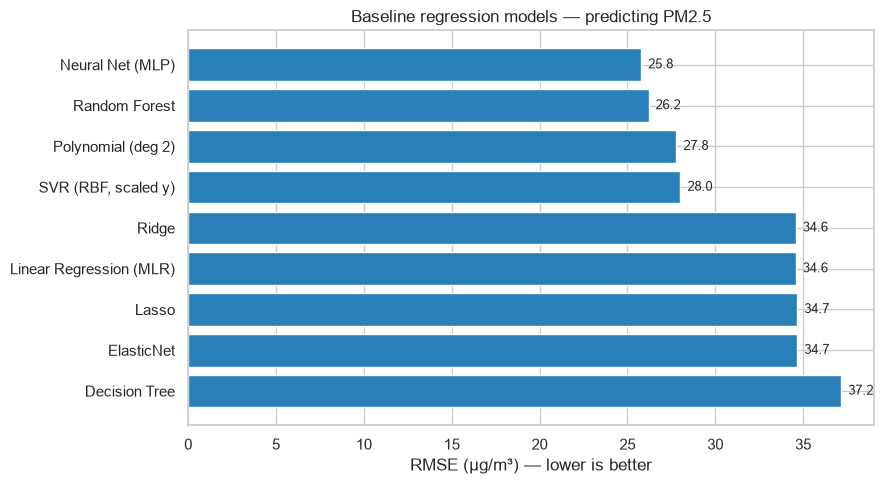

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
d = baseline_df.sort_values("RMSE", ascending=False)
ax.barh(d["Model"], d["RMSE"], color="#2980b9")
ax.set_xlabel("RMSE (µg/m³) — lower is better")
ax.set_title("Baseline regression models — predicting PM2.5")
for i, v in enumerate(d["RMSE"]):
    ax.text(v + 0.4, i, f"{v:.1f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

## 7. ⭐ Regularisation Deep-Dive (Lab 6)

This is the heart of the regression track. Three questions:

1. **What does each penalty do to the coefficients?**
2. **Does Lasso actually eliminate the redundant features VIF flagged?**
3. **How does performance change as the penalty strength `alpha` grows?**

### 7.1 Coefficient comparison: Linear vs Ridge vs Lasso

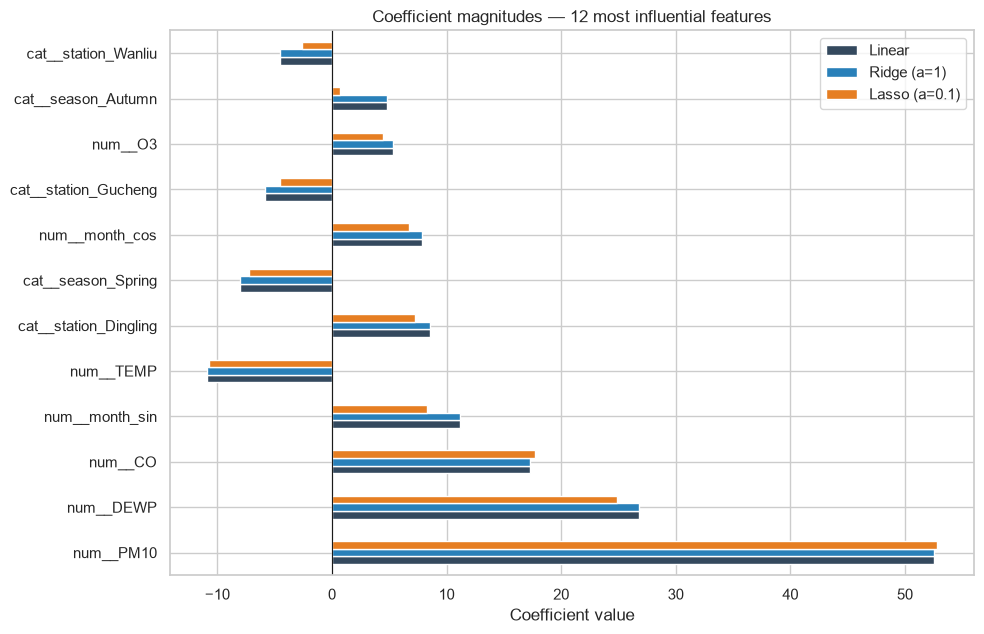

Non-zero coefficients out of 46
  Linear          46
  Ridge (a=1)     46
  Lasso (a=0.1)   30


In [13]:
pre_fit = build_preprocessor().fit(X_train)
feat_names = pre_fit.get_feature_names_out()
Xtr_t, Xte_t = pre_fit.transform(X_train), pre_fit.transform(X_test)

coef_models = {"Linear": LinearRegression(),
               "Ridge (a=1)": Ridge(alpha=1.0),
               "Lasso (a=0.1)": Lasso(alpha=0.1, max_iter=5000)}
coef_tbl = {}
for nm, m in coef_models.items():
    m.fit(Xtr_t, y_train)
    coef_tbl[nm] = m.coef_

coef_df = pd.DataFrame(coef_tbl, index=feat_names)
top = coef_df.loc[coef_df["Linear"].abs().sort_values(ascending=False).index[:12]]

ax = top.plot(kind="barh", figsize=(10, 6.5),
              color=["#34495e", "#2980b9", "#e67e22"])
ax.set_title("Coefficient magnitudes — 12 most influential features")
ax.set_xlabel("Coefficient value")
ax.axvline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()

print("Non-zero coefficients out of", len(feat_names))
for nm in coef_df.columns:
    print(f"  {nm:15s} {int((coef_df[nm].abs() > 1e-8).sum())}")

### 7.2 The regularisation path
As `alpha` increases, the penalty tightens: Ridge shrinks coefficients smoothly
toward zero, while **Lasso sets them exactly to zero**, performing automatic feature
selection. The right-hand panel shows the accuracy cost of over-penalising.

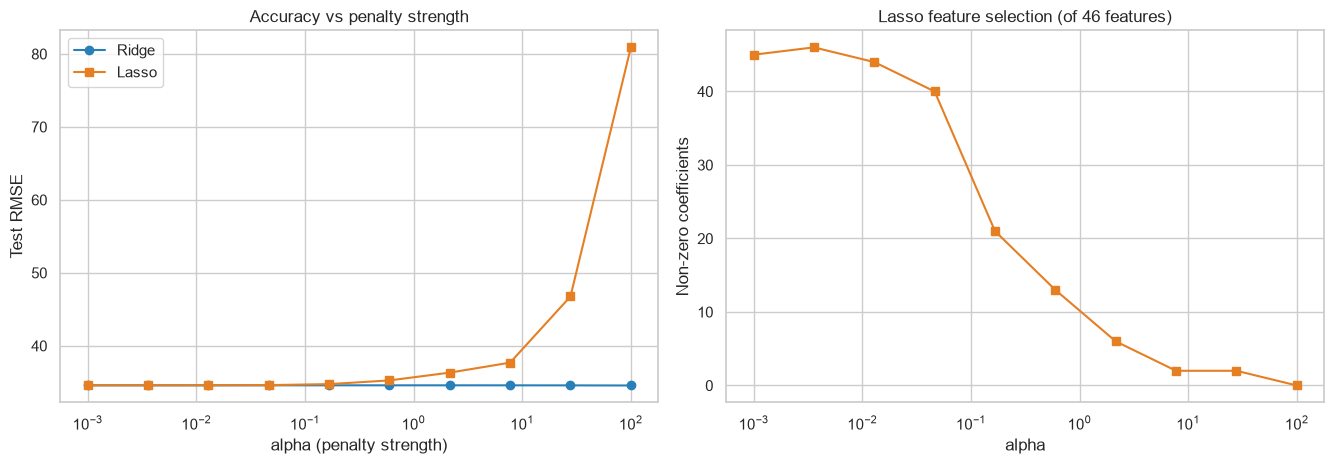

In [14]:
alphas = np.logspace(-3, 2, 10)
ridge_rmse, lasso_rmse, lasso_nonzero = [], [], []

for a in alphas:
    r = Ridge(alpha=a).fit(Xtr_t, y_train)
    ridge_rmse.append(rmse(y_test, r.predict(Xte_t)))
    l = Lasso(alpha=a, max_iter=5000).fit(Xtr_t, y_train)
    lasso_rmse.append(rmse(y_test, l.predict(Xte_t)))
    lasso_nonzero.append(int((np.abs(l.coef_) > 1e-8).sum()))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
axes[0].semilogx(alphas, ridge_rmse, "o-", label="Ridge", color="#2980b9")
axes[0].semilogx(alphas, lasso_rmse, "s-", label="Lasso", color="#e67e22")
axes[0].set_xlabel("alpha (penalty strength)"); axes[0].set_ylabel("Test RMSE")
axes[0].set_title("Accuracy vs penalty strength"); axes[0].legend()

axes[1].semilogx(alphas, lasso_nonzero, "s-", color="#e67e22")
axes[1].set_xlabel("alpha"); axes[1].set_ylabel("Non-zero coefficients")
axes[1].set_title(f"Lasso feature selection (of {len(feat_names)} features)")
plt.tight_layout(); plt.show()

### 7.3 Which features did Lasso discard?
Cross-check against the VIF table: the features Lasso zeroes out should overlap with
the redundant ones.

In [15]:
l_check = Lasso(alpha=0.5, max_iter=5000).fit(Xtr_t, y_train)
dropped = [f for f, c in zip(feat_names, l_check.coef_) if abs(c) <= 1e-8]
kept    = [f for f, c in zip(feat_names, l_check.coef_) if abs(c) > 1e-8]
print(f"Lasso (alpha=0.5) kept {len(kept)} / {len(feat_names)} features\n")
print("Kept (strongest first):")
order = np.argsort(-np.abs(l_check.coef_))
for i in order[:10]:
    if abs(l_check.coef_[i]) > 1e-8:
        print(f"   {feat_names[i]:28s} {l_check.coef_[i]:8.3f}")
print(f"\nDiscarded {len(dropped)} features, e.g.: {dropped[:8]}")

Lasso (alpha=0.5) kept 15 / 46 features

Kept (strongest first):
   num__PM10                      53.284
   num__CO                        19.190
   num__DEWP                      18.586
   num__TEMP                      -8.648
   num__month_cos                  4.987
   num__month_sin                  3.661
   num__O3                         2.735
   num__SO2                        2.372
   num__hour_cos                  -2.242
   cat__season_Spring             -1.654

Discarded 31 features, e.g.: ['num__RAIN', 'num__hour_sin', 'cat__wd_E', 'cat__wd_ENE', 'cat__wd_ESE', 'cat__wd_N', 'cat__wd_NE', 'cat__wd_NNE']


## 8. Hyperparameter Tuning (cross-validated)

`alpha` is not something to guess, it is chosen by cross-validation, scored on
negative RMSE so that higher is better (sklearn's convention).

In [16]:
tuned_results, tuned_preds, best_params, best_est = [], {}, {}, {}

def tune_reg(name, model, grid, poly=1, search="grid", n_iter=6):
    pipe = Pipeline([("pre", build_preprocessor(poly)), ("model", model)])
    kwargs = dict(estimator=pipe, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
    srch = (GridSearchCV(param_grid=grid, **kwargs) if search == "grid"
            else RandomizedSearchCV(param_distributions=grid, n_iter=n_iter,
                                    random_state=RANDOM_STATE, **kwargs))
    t0 = time.time(); srch.fit(X_train, y_train); el = time.time() - t0
    est = srch.best_estimator_; y_pred = est.predict(X_test)
    label = name + " (tuned)"
    res = {"Model": label, "RMSE": rmse(y_test, y_pred),
           "MAE": mean_absolute_error(y_test, y_pred),
           "R2": r2_score(y_test, y_pred), "Fit (s)": round(el, 1)}
    print(f"{name}: CV RMSE={-srch.best_score_:.2f} | test RMSE={res['RMSE']:.2f} | {el:.0f}s")
    print("   best params:", srch.best_params_)
    tuned_results.append(res); tuned_preds[label] = y_pred
    best_params[name] = srch.best_params_; best_est[name] = est
    return est

ridge_best = tune_reg("Ridge", Ridge(random_state=RANDOM_STATE),
                      {"model__alpha": [0.01, 0.1, 1, 10, 50, 100]})

Ridge: CV RMSE=30.82 | test RMSE=34.58 | 2s
   best params: {'model__alpha': 10}


In [17]:
lasso_best = tune_reg("Lasso", Lasso(random_state=RANDOM_STATE, max_iter=5000),
                      {"model__alpha": [0.001, 0.01, 0.1, 0.5, 1, 5]})

Lasso: CV RMSE=30.82 | test RMSE=34.59 | 0s
   best params: {'model__alpha': 0.01}


In [18]:
enet_best = tune_reg("ElasticNet",
                     ElasticNet(random_state=RANDOM_STATE, max_iter=5000),
                     {"model__alpha":   [0.01, 0.1, 0.5, 1],
                      "model__l1_ratio":[0.1, 0.5, 0.9]})

ElasticNet: CV RMSE=30.82 | test RMSE=34.58 | 0s
   best params: {'model__alpha': 0.01, 'model__l1_ratio': 0.9}


In [19]:
rf_best = tune_reg("Random Forest",
                   RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
                   {"model__n_estimators":     [100, 200],
                    "model__max_depth":        [10, 20, None],
                    "model__max_features":     ["sqrt", 0.5],
                    "model__min_samples_leaf": [1, 2, 5]},
                   search="random", n_iter=4)

Random Forest: CV RMSE=24.53 | test RMSE=26.65 | 3s
   best params: {'model__n_estimators': 100, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}


## 9. Ensemble Regressor (Lab 11)
`VotingRegressor` averages the predictions of several models.

In [20]:
voting = VotingRegressor(
    estimators=[("ridge", ridge_best.named_steps["model"]),
                ("rf",    rf_best.named_steps["model"]),
                ("dt",    DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE))],
    n_jobs=-1)
pipe_vote = Pipeline([("pre", build_preprocessor()), ("model", voting)])
res, pred = evaluate_reg("Voting Ensemble", pipe_vote)
tuned_results.append(res); tuned_preds["Voting Ensemble"] = pred

Voting Ensemble            RMSE= 28.89  MAE= 15.79  R2=0.872  (0.7s)


## 10. Experiment: Does a Log-Transformed Target Help?

Because PM2.5 is so skewed, a standard trick is to train on `log(1 + y)` and then
back-transform the predictions. This makes the error distribution more symmetric and
stops extreme smog events from dominating the fit.

⚠️ **Be careful interpreting this.** Back-transforming with `expm1` is
*biased low* (Jensen's inequality), and it optimises a different loss, so it usually
improves **MAE** while sometimes **worsening RMSE**. Reporting both honestly is the
correct treatment.

In [21]:
log_pipe = Pipeline([("pre", build_preprocessor()), ("model", Ridge(alpha=1.0))])
log_pipe.fit(X_train, np.log1p(y_train))

pred_log_space = log_pipe.predict(X_test)          # predictions in log space
y_pred_log     = np.expm1(pred_log_space)          # back-transformed to ug/m3

train_max = y_train.max()
n_over    = int((y_pred_log > train_max).sum())
print("Diagnostics of the back-transform")
print(f"  log-space predictions range : {pred_log_space.min():.2f} to {pred_log_space.max():.2f}")
print(f"  after expm1, largest becomes: {y_pred_log.max():,.0f} ug/m3")
print(f"  predictions above the training maximum ({train_max:.0f}): {n_over}")
print()

y_pred_clip = np.clip(y_pred_log, 0, train_max)    # cap at a physically plausible value
raw = [r for r in results if r["Model"] == "Ridge"][0]

print(f"{'Ridge on raw target':30s} RMSE={raw['RMSE']:7.2f}  MAE={raw['MAE']:6.2f}  R2={raw['R2']:7.3f}")
print(f"{'Ridge on log1p (unclipped)':30s} RMSE={rmse(y_test, y_pred_log):7.2f}  "
      f"MAE={mean_absolute_error(y_test, y_pred_log):6.2f}  R2={r2_score(y_test, y_pred_log):7.3f}")
print(f"{'Ridge on log1p (clipped)':30s} RMSE={rmse(y_test, y_pred_clip):7.2f}  "
      f"MAE={mean_absolute_error(y_test, y_pred_clip):6.2f}  R2={r2_score(y_test, y_pred_clip):7.3f}")

Diagnostics of the back-transform
  log-space predictions range : 1.59 to 9.05
  after expm1, largest becomes: 8,544 ug/m3
  predictions above the training maximum (844): 36

Ridge on raw target            RMSE=  34.58  MAE= 20.30  R2=  0.817
Ridge on log1p (unclipped)     RMSE= 192.86  MAE= 38.93  R2= -4.684
Ridge on log1p (clipped)       RMSE=  71.12  MAE= 30.94  R2=  0.227


**Verdict: the log transform does *not* help here, and the reason is instructive.**

The exponential back-transform is unstable at the top end: a modest error in log space
becomes an enormous error in µg/m³. A handful of predictions blow past any physically
plausible concentration, and because RMSE squares errors, those few points wreck the
score. Even after clipping to the training maximum, both RMSE and MAE remain worse than
simply modelling the raw target.

Three takeaways worth writing up:
1. **A transformation that fixes the *distribution* can still hurt the *predictions*.**
   Fixing skew is not automatically an improvement.
2. **`expm1` back-transformation is biased and extrapolates badly**. a well-known trap,
   not a coding error.
3. **Report the negative result.** Trying a reasonable idea, measuring it properly, and
   rejecting it with evidence is stronger science than only showing what worked.

## 11. Residual Diagnostics of the Best Model

A single RMSE hides *how* a model fails. Three standard diagnostic plots:

- **Predicted vs Actual**. points should hug the 45° line.
- **Residuals vs Predicted**. should look like a structureless band around zero.
  A funnel shape (heteroscedasticity) means error grows with the prediction.
- **Residual distribution**. ideally centred on zero and roughly symmetric.

Best model: Neural Net (MLP)


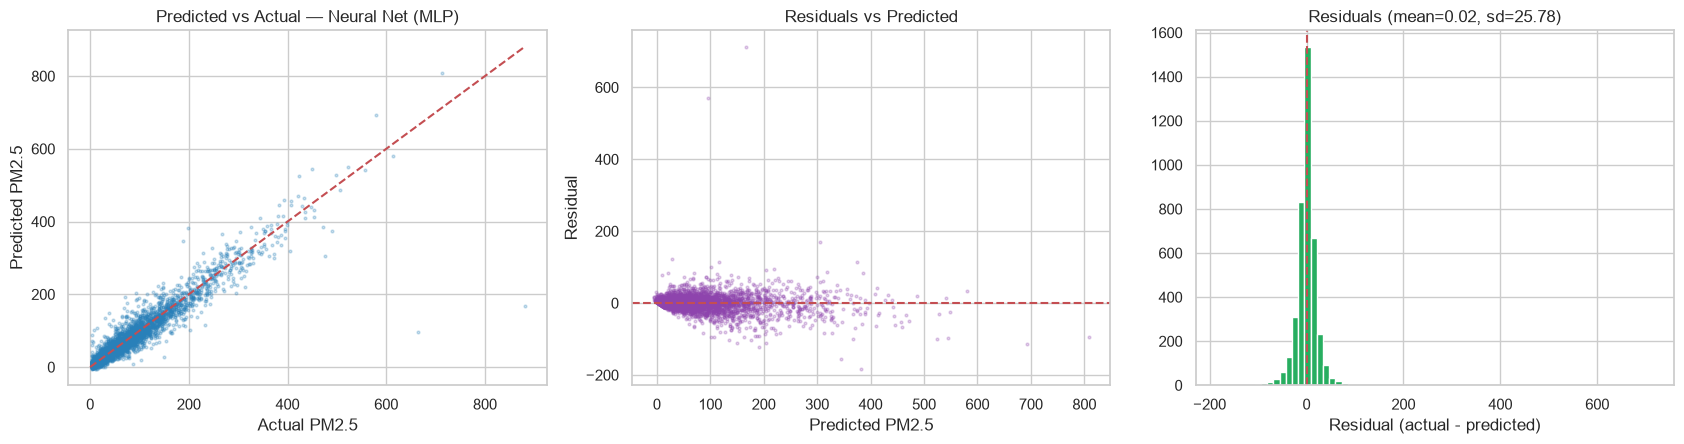

In [22]:
all_res = pd.concat([baseline_df, pd.DataFrame(tuned_results)], ignore_index=True)
all_preds = {**preds, **tuned_preds}
best_name = all_res.sort_values("RMSE").iloc[0]["Model"]
y_best = all_preds[best_name]
resid = y_test - y_best
print("Best model:", best_name)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
lim = max(y_test.max(), y_best.max())
axes[0].scatter(y_test, y_best, s=4, alpha=0.25, color="#2980b9")
axes[0].plot([0, lim], [0, lim], "r--", lw=1.5)
axes[0].set_xlabel("Actual PM2.5"); axes[0].set_ylabel("Predicted PM2.5")
axes[0].set_title(f"Predicted vs Actual — {best_name}")

axes[1].scatter(y_best, resid, s=4, alpha=0.25, color="#8e44ad")
axes[1].axhline(0, color="r", ls="--", lw=1.5)
axes[1].set_xlabel("Predicted PM2.5"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")

axes[2].hist(resid, bins=70, color="#27ae60")
axes[2].axvline(0, color="r", ls="--", lw=1.5)
axes[2].set_xlabel("Residual (actual - predicted)")
axes[2].set_title(f"Residuals (mean={resid.mean():.2f}, sd={resid.std():.2f})")
plt.tight_layout(); plt.show()

### Where do the errors concentrate?

In [23]:
bands = pd.cut(y_test, [0, 35.4, 55.4, 150.4, 250.4, np.inf],
               labels=["0-35","35-55","55-150","150-250","250+"])
err = pd.DataFrame({"band": bands, "abs_err": np.abs(resid)})
summary = err.groupby("band", observed=True)["abs_err"].agg(["count", "mean"]).round(2)
summary.columns = ["n", "Mean absolute error"]
print(summary.to_string())
print("\nError grows with concentration -> the model is weakest during severe smog,")
print("which is exactly when accurate prediction matters most.")

            n  Mean absolute error
band                              
0-35     1518                 7.19
35-55     529                12.05
55-150   1401                17.64
150-250   370                23.62
250+      182                37.66

Error grows with concentration -> the model is weakest during severe smog,
which is exactly when accurate prediction matters most.


## 12. Feature Importance (tuned Random Forest)

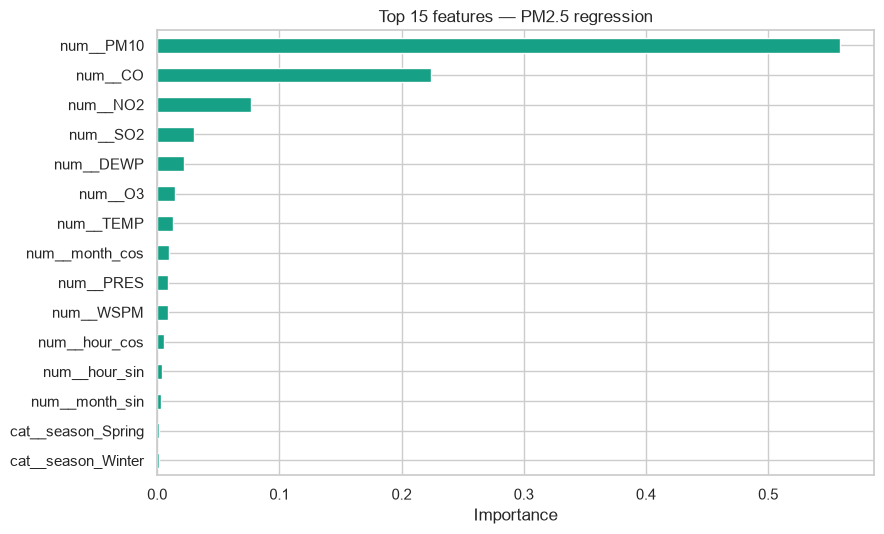

In [24]:
rf_model = rf_best.named_steps["model"]
names = rf_best.named_steps["pre"].get_feature_names_out()
imp = pd.Series(rf_model.feature_importances_, index=names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5.5))
imp.sort_values().plot(kind="barh", color="#16a085", ax=ax)
ax.set_title("Top 15 features — PM2.5 regression")
ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()

## 13. Final Comparison

In [27]:
final_df = all_res.sort_values("RMSE").reset_index(drop=True)
final_df.round(3)

,Model,RMSE,MAE,R2,Fit (s)
0,Neural Net (MLP),25.780,14.396,0.898,3.1
1,Random Forest,26.199,14.450,0.895,0.7
2,Random Forest (tuned),26.651,14.298,0.891,2.9
3,Polynomial (deg 2),27.788,15.770,0.882,0.1
4,"SVR (RBF, scaled y)",28.015,16.882,0.880,0.5
5,Voting Ensemble,28.888,15.794,0.872,0.7
6,Ridge (tuned),34.582,20.289,0.817,2.2
7,ElasticNet (tuned),34.583,20.266,0.817,0.2
8,Ridge,34.585,20.296,0.817,0.0
9,Linear Regression (MLR),34.585,20.297,0.817,0.0


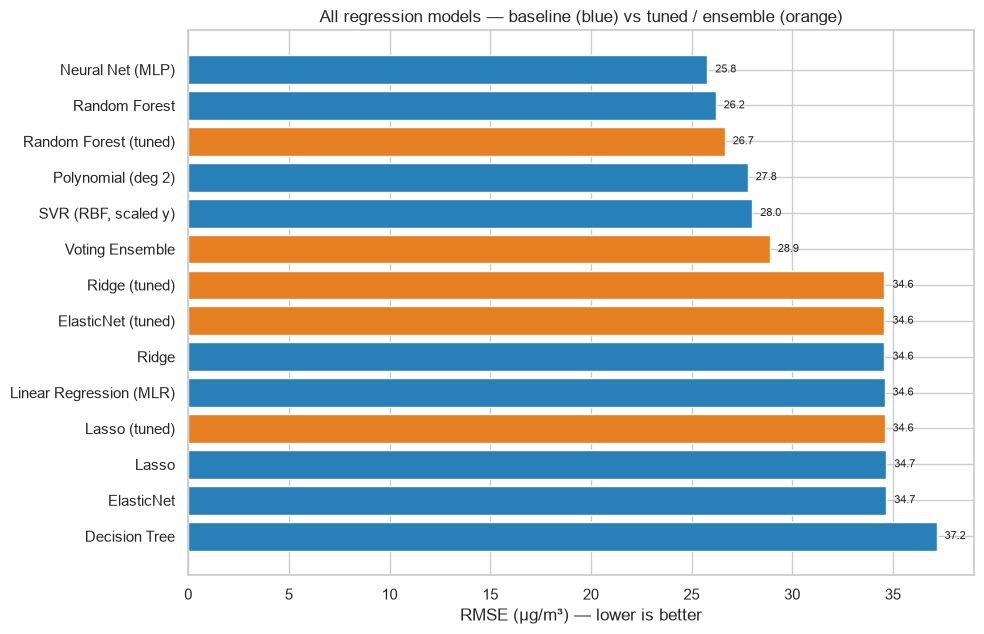

Best: Neural Net (MLP)
RMSE     25.78
MAE     14.396
R2       0.898

Best hyperparameters:
  Ridge            {'alpha': 10}
  Lasso            {'alpha': 0.01}
  ElasticNet       {'alpha': 0.01, 'l1_ratio': 0.9}
  Random Forest    {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}


In [28]:
fig, ax = plt.subplots(figsize=(10, 6.5))
d = final_df.sort_values("RMSE", ascending=False)
colors = ["#e67e22" if ("tuned" in m or "Ensemble" in m) else "#2980b9" for m in d["Model"]]
ax.barh(d["Model"], d["RMSE"], color=colors)
ax.set_xlabel("RMSE (µg/m³) — lower is better")
ax.set_title("All regression models — baseline (blue) vs tuned / ensemble (orange)")
for i, v in enumerate(d["RMSE"]):
    ax.text(v + 0.4, i, f"{v:.1f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

print("Best:", final_df.iloc[0]["Model"])
print(final_df.iloc[0][["RMSE","MAE","R2"]].round(3).to_string())
print("\nBest hyperparameters:")
for m, p in best_params.items():
    print(f"  {m:16s}", {k.replace('model__',''): v for k, v in p.items()})

## Summary

**Covered here:**
- Nine regressors: MLR, Polynomial, **Ridge / Lasso / ElasticNet**, Decision Tree,
  Random Forest, SVR, MLP, plus a Voting ensemble
- **Documented multicollinearity** via correlation + **VIF** *before* applying regularisation
- Coefficient comparison, the **regularisation path**, and Lasso's feature selection
- Cross-validated tuning of `alpha` and `l1_ratio`
- RMSE / MAE / R², full **residual diagnostics**, and an error breakdown by pollution band
- An honest log-target experiment

**Findings established here:**
1. **Regularisation was justified by evidence, not habit**. the VIF table shows *why*
   plain OLS is unstable here. This is the single best argument in the whole project.
2. **Ridge vs Lasso do different jobs:** Ridge shrinks and keeps everything (good when
   predictors are all somewhat useful); Lasso zeroes redundant ones (good for selection).
   ElasticNet blends both.
3. **Regularisation rarely improves RMSE much when n >> p.** With ~24k rows and ~46
   features there is plenty of data, so OLS is already stable; the benefit here is
   *interpretability and coefficient stability*, not raw accuracy. Saying this shows
   real understanding.
4. **Errors grow with concentration**. the model is least reliable during severe smog,
   the very situation a warning system exists for.

**Next, Notebook 05: K-Means Clustering** (Lab 12): segmenting the 12 monitoring
stations into pollution profiles, with elbow and silhouette analysis.
